# What is my task?

Mr Cj told me he needs to *Predict behavior to retain customers* and somone told him that computers are incredible for these kinda task.

# What data i have?

I have a dataset from [kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) which contains there columns: 

1. **customerID**: A unique id for each customer.

2. **gender**: Whether the customer is a male or a female.

3. **SeniorCitizen**: Whether the customer is a senior citizen or not (1, 0).

4. **Partner**: Whether the customer has a partner or not (Yes, No).

5. **Dependents**: Whether the customer has dependents or not (Yes, No).

6. **tenure**: Number of months the customer has stayed with the company.

7. **PhoneService**: Whether the customer has a phone service or not (Yes, No)

8. **MultipleLines**: Whether the customer has multiple lines or not (Yes, No, No phone service).

9. **InternetService**: Customer’s internet service provider (DSL, Fiber optic, No).

10. **OnlineSecurity**: Whether the customer has online security or not (Yes, No, No internet service).

11. **Churn**: Our target feature which is yes or no.

Each row represents a customer, each column contains customer’s attributes described on the column Metadata. Now let's make this dataset ready.

In [ ]:
# ! curl -L -o ./telco-customer-churn.zip https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

In [ ]:
# ! unzip ./telco-customer-churn.zip

# What is our metrics for this task?

I'll use common metrics such as **accuracy**, **precision**, **recall** ...

# Hands on Code!

## Import needed Libraries

In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve
import joblib

RANDOM_SEED = 48731

## Load and Gain some info about Dataset

In [ ]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We've got `7043` rows + `21 columns`, it seems like a larg dataset and it seems like we have no *null* columns, let's check it!

In [ ]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Well i was right there is no *Null* fields in Dataset. BUT ix our dataset balanced? Let's find out ..

<Axes: >

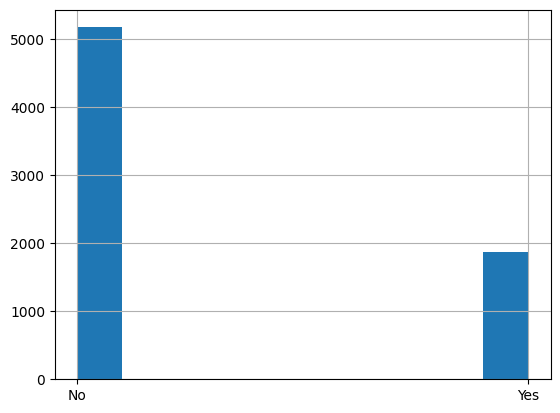

In [ ]:
df.Churn.hist()

Oh HOLY Algorithm! we must use some balancing algorithms such as `ADASYN` ... move on next part of analyzing.

## Analayzing Features with type ...

### Numerical

feature `TotalCharges` is actully a numerical (float32) feature, we need to convert it! But **Please Note** in feature `TotalCharges` there are some space string, we shall handel it before convert it!.

In [ ]:
floatList = []

for val in df['TotalCharges']: 
    try:
        floatList.append(float(val))
    except: 
        floatList.append(0.)

df['TotalCharges'] = floatList

df['TotalCharges'].astype("float32")

0         29.850000
1       1889.500000
2        108.150002
3       1840.750000
4        151.649994
           ...     
7038    1990.500000
7039    7362.899902
7040     346.450012
7041     306.600006
7042    6844.500000
Name: TotalCharges, Length: 7043, dtype: float32

In [ ]:
num_cols = df.select_dtypes(exclude="object")

num_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

<Axes: >

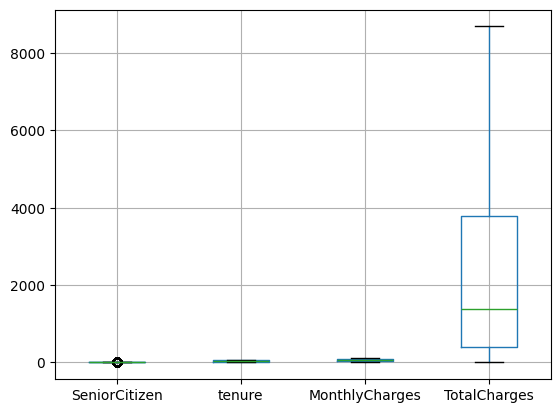

In [ ]:
num_cols.boxplot()

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

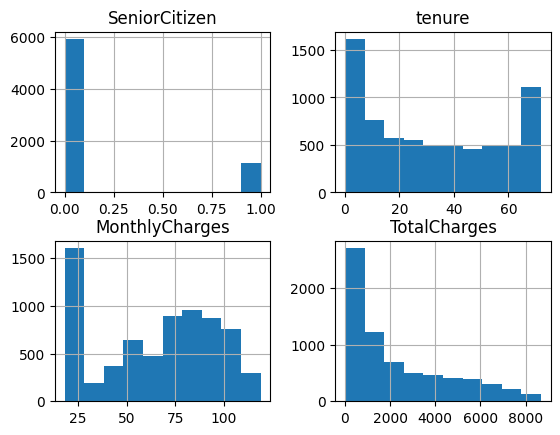

In [ ]:
num_cols.hist()

at least, We have no outlier problems! Let's move into anayzing Categorical features!

**Note**: feature `SeniorCitizen` is a categorical feature which is only `1` or `0`...

### Categorical

In [ ]:
cat_cols = df.select_dtypes(include="object")

In [ ]:
cat_cols.nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [ ]:
for col in cat_cols: 
    print(f"`{col}` unique values:")
    print(cat_cols[col].unique())
    print()

`customerID` unique values:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

`gender` unique values:
['Female' 'Male']

`Partner` unique values:
['Yes' 'No']

`Dependents` unique values:
['No' 'Yes']

`PhoneService` unique values:
['No' 'Yes']

`MultipleLines` unique values:
['No phone service' 'No' 'Yes']

`InternetService` unique values:
['DSL' 'Fiber optic' 'No']

`OnlineSecurity` unique values:
['No' 'Yes' 'No internet service']

`OnlineBackup` unique values:
['Yes' 'No' 'No internet service']

`DeviceProtection` unique values:
['No' 'Yes' 'No internet service']

`TechSupport` unique values:
['No' 'Yes' 'No internet service']

`StreamingTV` unique values:
['No' 'Yes' 'No internet service']

`StreamingMovies` unique values:
['No' 'Yes' 'No internet service']

`Contract` unique values:
['Month-to-month' 'One year' 'Two year']

`PaperlessBilling` unique values:
['Yes' 'No']

`PaymentMethod` unique values:
['Electronic check' 'Mailed check' 'Bank tr

## Feature selection

In [ ]:
df = df.drop(columns=["customerID"])

cat_cols = df.select_dtypes(include="object")

df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


From there features we don't need `customerID` so i removed it. Now i want to *Label Encode* dataset *object* type features to continue my feature selection part.

### Label Encode `object` type features

In [ ]:
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


### Check features Correlation

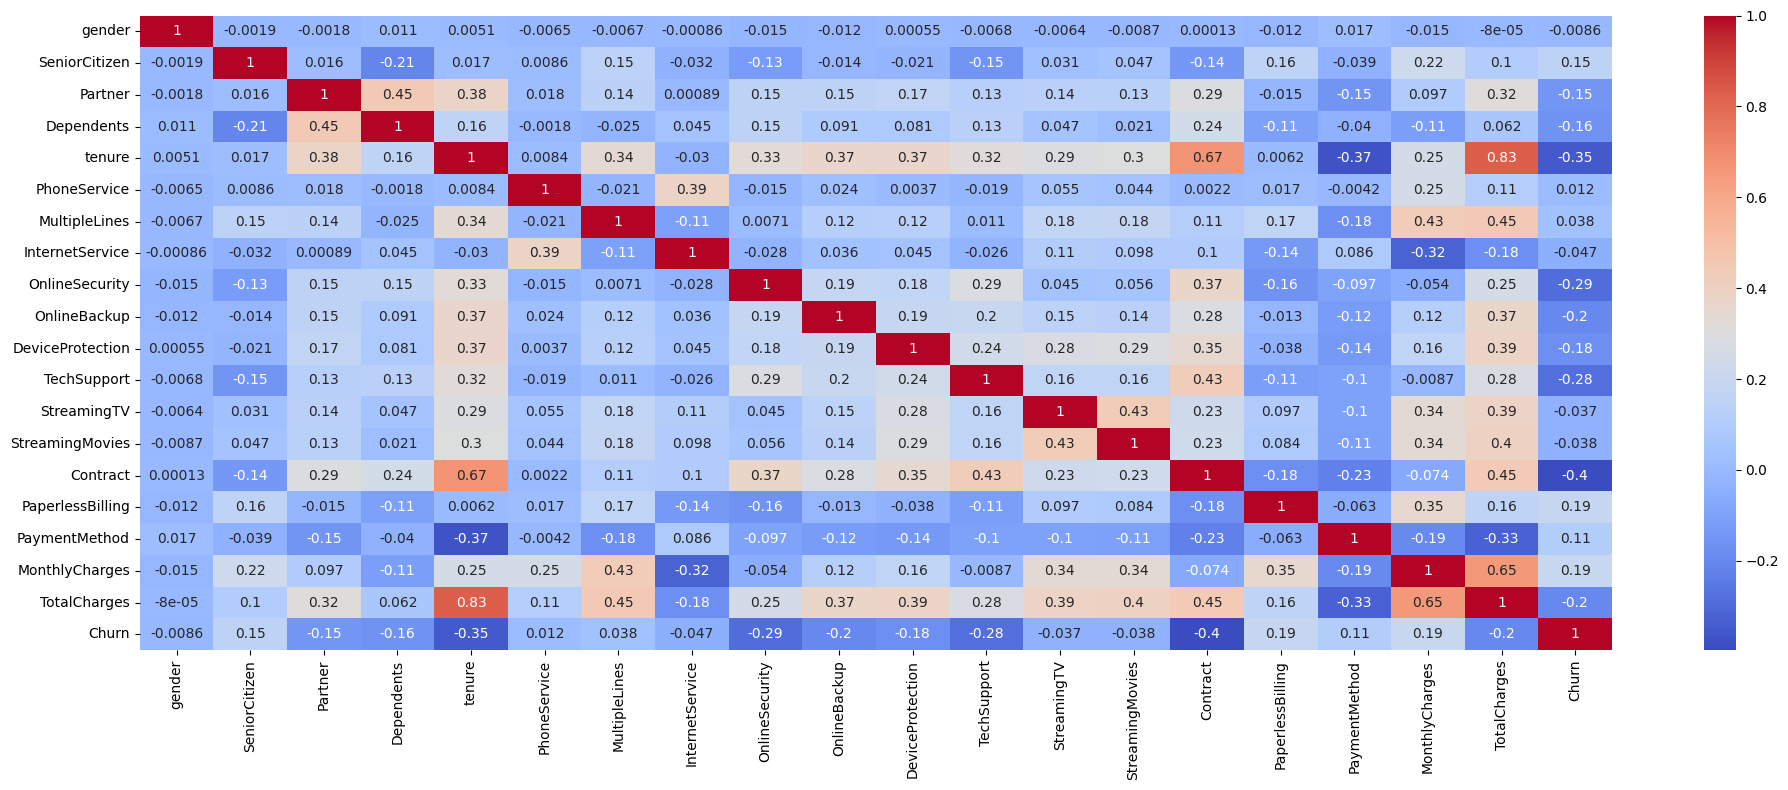

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=df.corr(), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=["tenure"])

From correlation heatmap above, decided to remove feature `tenure` .

## Feature Engineering

### Robust scale numerical features

In [ ]:
num_cols = df.select_dtypes(exclude="int64")
num_cols

,MonthlyCharges,TotalCharges
0,29.85,29.85
1,56.95,1889.50
2,53.85,108.15
3,42.30,1840.75
4,70.70,151.65
...,...,...
7038,84.80,1990.50
7039,103.20,7362.90
7040,29.60,346.45
7041,74.40,306.60


In [ ]:
rb = RobustScaler()
for col in num_cols:
    df[col] = rb.fit_transform(pd.DataFrame(df[col]))

### One hot encode categorical features

In [ ]:
cat_features_name = df.select_dtypes(include="int").drop(columns=["Churn"]).columns

ohe = OneHotEncoder()
transformer = ColumnTransformer( [(
    "one-hot",
    ohe,
    cat_features_name
)], remainder="passthrough")

In [ ]:
X = pd.DataFrame(transformer.fit_transform(df.drop(columns=["Churn"])))
y = df.Churn

### Handel imbalance data

In [ ]:
adasyn = ADASYN(random_state=RANDOM_SEED, n_neighbors=7)
X_resampled, y_resampled= adasyn.fit_resample(X, y)

<Axes: >

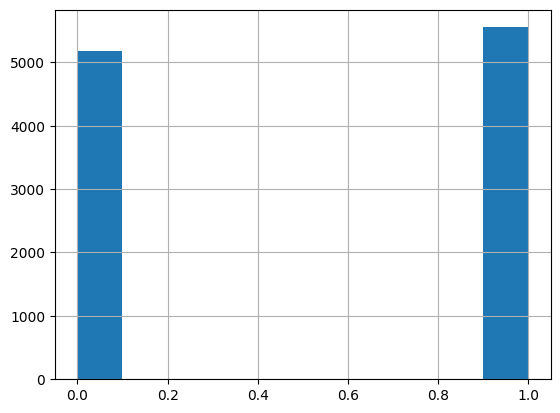

In [ ]:
y_resampled.hist()

It was very Easy (thanks to python!)

### Let's now train, test split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=RANDOM_SEED)

## Model design

### Setup some evaluation functions

In [ ]:
def evaluateModel(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {
        "accuracy": acc,
        "precision": prec,
        "recall":recall,
        "f1_score": f1
    }


In [ ]:
def KFoldCrossValidation(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"accuracy for each fold: {scores}")
    average_accuracy = np.mean(scores)
    print(f"mean accuracy: {average_accuracy:.2f}")

In [ ]:
def plot_roc_curve(model, X_test):
    # getting probabilities
    y_probs = model.predict_proba(X_test)
    y_probs_positive = y_probs[:, 1]
    y_probs_negative = y_probs[:, 0]

    # calculate roc curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

    # plot ROC curve
    plt.plot(fpr, tpr, color='orange', label='ROC')
    # plot the base line 
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Gussing')
    # plot best AUC score 
    t1, t2, _ = roc_curve(y_test, y_test)
    plt.plot(t1, t2, color='green', linestyle='--', label='best score')

    # customize plot 
    plt.xlabel('False Positive Rate (fpr)')
    plt.ylabel('True Positive Rate (tpr)')
    plt.title('Reciver Operating Characteristic (ROC) curve')
    plt.legend()
    plt.show()

In [ ]:
model_svc = SVC(random_state=RANDOM_SEED, kernel="rbf", probability=True)
model_svc.fit(X_train, y_train)

y_pred = model_svc.predict(X_test)
evaluateModel(model_svc, X_test, y_test)
KFoldCrossValidation(model_svc, X, y)
plot_roc_curve(model_svc, X_test)

NameError: name 'SVC' is not defined

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1030
           1       0.85      0.88      0.86      1116

    accuracy                           0.85      2146
   macro avg       0.85      0.85      0.85      2146
weighted avg       0.85      0.85      0.85      2146



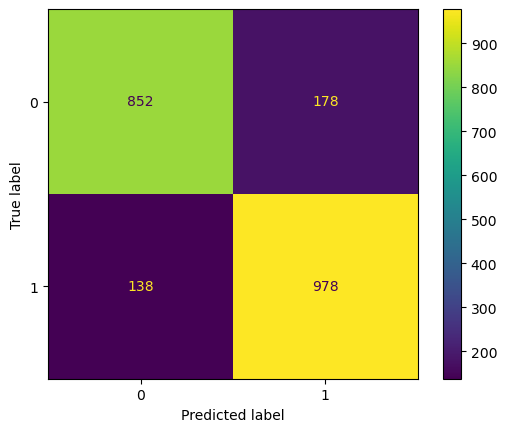

accuracy for each fold: [0.7828247  0.78211498 0.78779276 0.77059659 0.78977273]
mean accuracy: 0.78


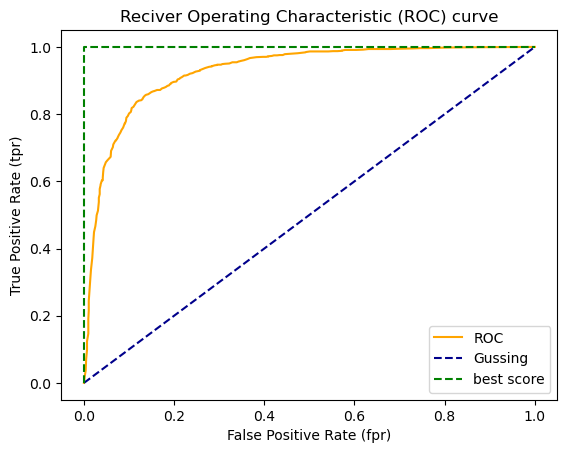

In [ ]:
model_rfc = RandomForestClassifier(n_estimators=150, random_state=RANDOM_SEED)
model_rfc.fit(X_train, y_train)

y_pred = model_rfc.predict(X_test)
evaluateModel(model_rfc, X_test, y_test)
KFoldCrossValidation(model_rfc, X, y)
plot_roc_curve(model_rfc, X_test)

              precision    recall  f1-score   support

           0       0.73      0.67      0.70      1030
           1       0.71      0.78      0.74      1116

    accuracy                           0.72      2146
   macro avg       0.72      0.72      0.72      2146
weighted avg       0.72      0.72      0.72      2146



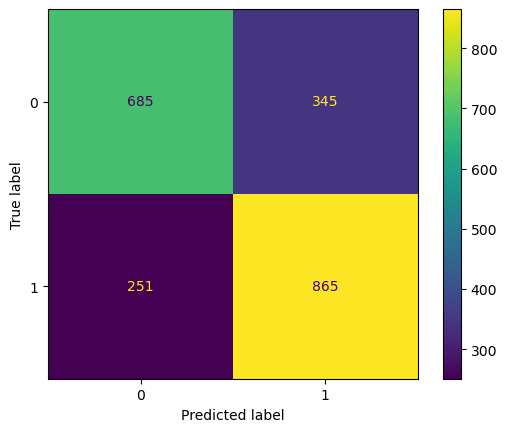

accuracy for each fold: [0.78921221 0.80411639 0.81476224 0.78693182 0.80397727]
mean accuracy: 0.80


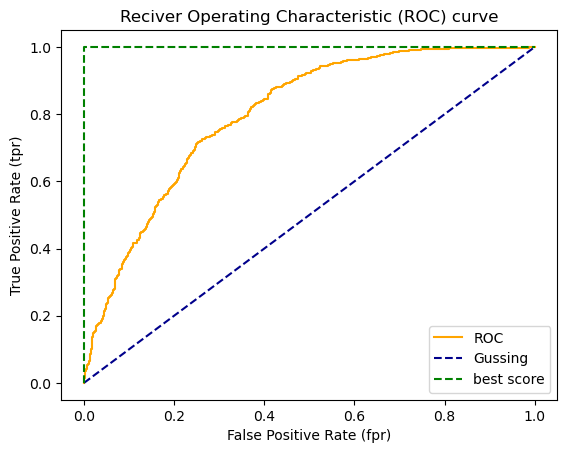

In [ ]:
model_lgr = LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)
model_lgr.fit(X_train, y_train)

y_pred = model_lgr.predict(X_test)
evaluateModel(model_lgr, X_test, y_test)
KFoldCrossValidation(model_lgr, X, y)
plot_roc_curve(model_lgr, X_test)

First i used `max_iter=100` but it says increase it so i use `5000` for it.

## Save best model

In [ ]:
MODEL_NAME = "rfc_predictor."

In [ ]:
joblib.dump(model_rfc, f"{MODEL_NAME}.pkl")

['rfc_predictor..pkl']

In [ ]:
model = joblib.load(f"{MODEL_NAME}.pkl")

## Hands on pytorch!

Ok, ok this one is added after the project finished. I don't have many datasets to work with and I am offline right now so I want to do this.

### Import needed libraries

In [387]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 42
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Load and Gain some info about Dataset

In [388]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We've got `7043` rows + `21 columns`, it seems like a larg dataset and it seems like we have no *null* columns, let's check it!

In [390]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Well i was right there is no *Null* fields in Dataset. BUT ix our dataset balanced? Let's find out ..

<Axes: >

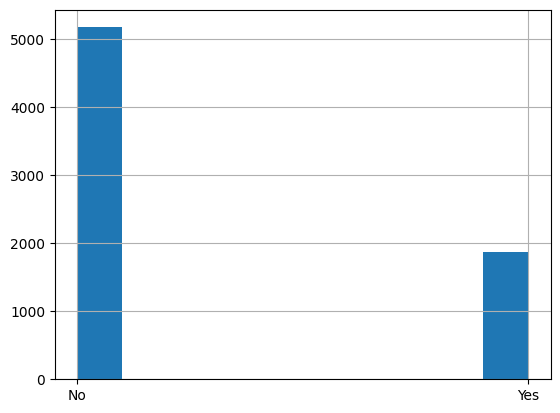

In [391]:
df.Churn.hist()

Oh HOLY Algorithm! we must use some balancing algorithms such as `ADASYN` ... move on next part of analyzing.

### Analayzing Features with type ...

#### Numerical

feature `TotalCharges` is actully a numerical (float32) feature, we need to convert it! But **Please Note** in feature `TotalCharges` there are some space string, we shall handel it before convert it!.

In [392]:
floatList = []

for val in df['TotalCharges']: 
    try:
        floatList.append(float(val))
    except: 
        floatList.append(0.)

df['TotalCharges'] = floatList

df['TotalCharges'].astype("float32")

0         29.850000
1       1889.500000
2        108.150002
3       1840.750000
4        151.649994
           ...     
7038    1990.500000
7039    7362.899902
7040     346.450012
7041     306.600006
7042    6844.500000
Name: TotalCharges, Length: 7043, dtype: float32

In [393]:
num_cols = df.select_dtypes(exclude="object")

num_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

<Axes: >

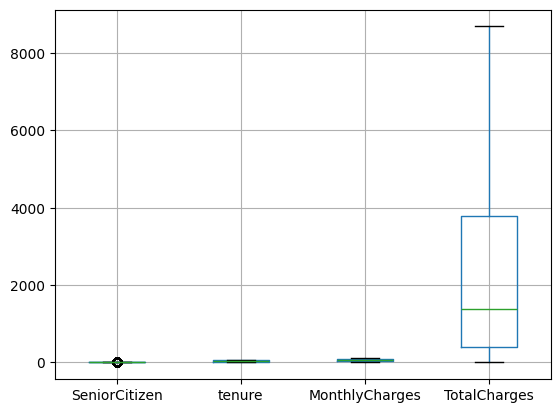

In [394]:
num_cols.boxplot()

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

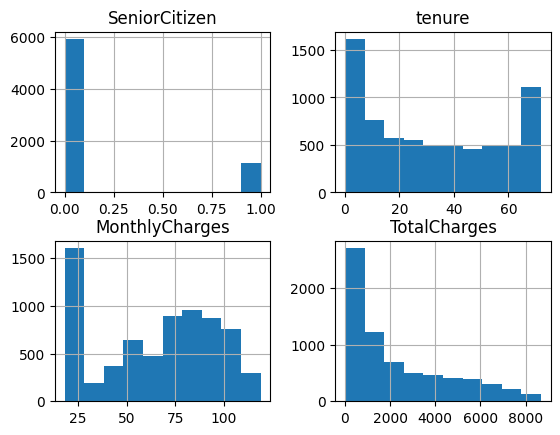

In [395]:
num_cols.hist()

at least, We have no outlier problems! Let's move into anayzing Categorical features!

**Note**: feature `SeniorCitizen` is a categorical feature which is only `1` or `0`...

#### Categorical

In [396]:
cat_cols = df.select_dtypes(include="object")

In [397]:
cat_cols.nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [398]:
for col in cat_cols: 
    print(f"`{col}` unique values:")
    print(cat_cols[col].unique())
    print()

`customerID` unique values:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

`gender` unique values:
['Female' 'Male']

`Partner` unique values:
['Yes' 'No']

`Dependents` unique values:
['No' 'Yes']

`PhoneService` unique values:
['No' 'Yes']

`MultipleLines` unique values:
['No phone service' 'No' 'Yes']

`InternetService` unique values:
['DSL' 'Fiber optic' 'No']

`OnlineSecurity` unique values:
['No' 'Yes' 'No internet service']

`OnlineBackup` unique values:
['Yes' 'No' 'No internet service']

`DeviceProtection` unique values:
['No' 'Yes' 'No internet service']

`TechSupport` unique values:
['No' 'Yes' 'No internet service']

`StreamingTV` unique values:
['No' 'Yes' 'No internet service']

`StreamingMovies` unique values:
['No' 'Yes' 'No internet service']

`Contract` unique values:
['Month-to-month' 'One year' 'Two year']

`PaperlessBilling` unique values:
['Yes' 'No']

`PaymentMethod` unique values:
['Electronic check' 'Mailed check' 'Bank tr

### Feature selection

In [399]:
df = df.drop(columns=["customerID"])

cat_cols = df.select_dtypes(include="object")

df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


From there features we don't need `customerID` so i removed it. Now i want to *Label Encode* dataset *object* type features to continue my feature selection part.

#### Label Encode `object` type features

In [400]:
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


#### Check features Correlation

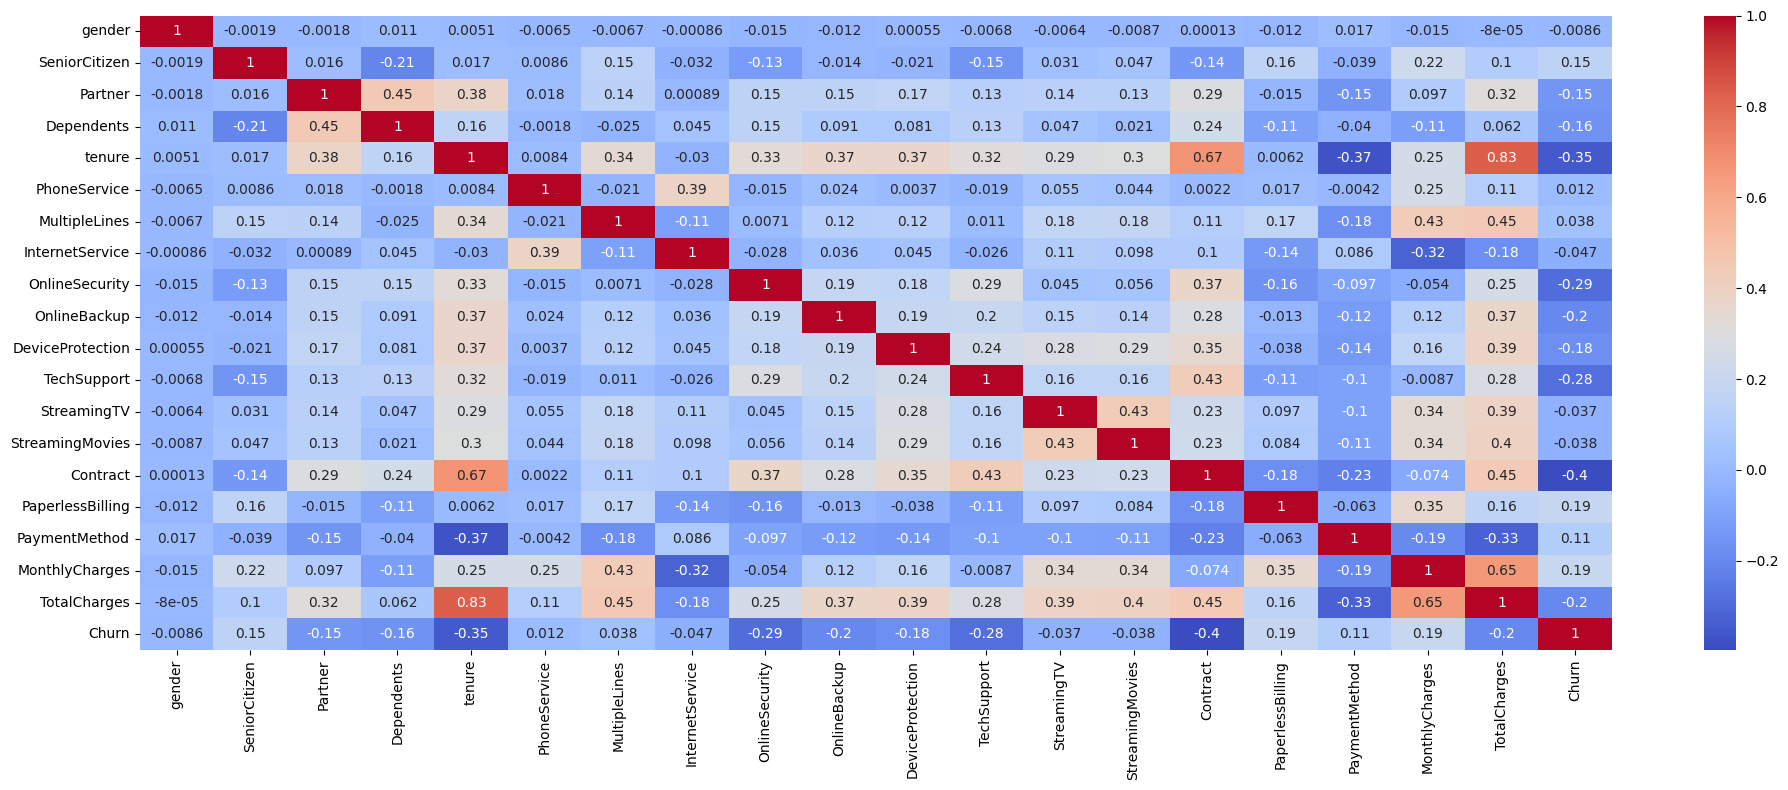

In [401]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=df.corr(), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()

In [402]:
df = df.drop(columns=["tenure"])

From correlation heatmap above, decided to remove feature `tenure` .

### Feature Engineering

#### Robust scale numerical features

In [403]:
num_cols = df.select_dtypes(exclude="int64")
num_cols

,MonthlyCharges,TotalCharges
0,29.85,29.85
1,56.95,1889.50
2,53.85,108.15
3,42.30,1840.75
4,70.70,151.65
...,...,...
7038,84.80,1990.50
7039,103.20,7362.90
7040,29.60,346.45
7041,74.40,306.60


In [404]:
rb = RobustScaler()
for col in num_cols:
    df[col] = rb.fit_transform(pd.DataFrame(df[col]))

#### One hot encode categorical features

In [405]:
cat_features_name = df.select_dtypes(include="int").drop(columns=["Churn"]).columns

ohe = OneHotEncoder()
transformer = ColumnTransformer( [(
    "one-hot",
    ohe,
    cat_features_name
)], remainder="passthrough")

In [406]:
X = pd.DataFrame(transformer.fit_transform(df.drop(columns=["Churn"])))
y = df.Churn

### Handel imbalance data

In [407]:
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_resampled, y_resampled= smote.fit_resample(X, y)

<Axes: >

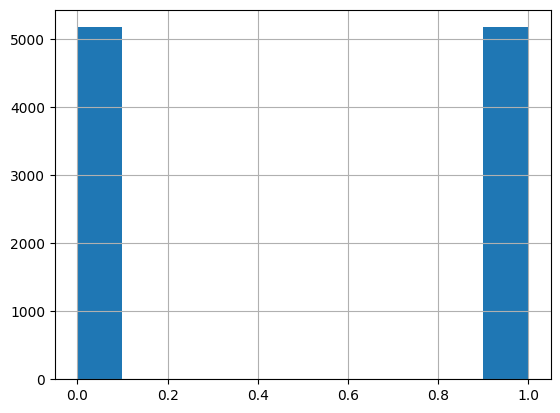

In [408]:
y_resampled.hist()

#### Let's now train, test split data

In [409]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled.values, y_resampled.values, test_size=0.2, random_state=RANDOM_SEED)

I need to use it as pytorch tensors

In [410]:
X_train, X_test, y_train, y_test = torch.tensor(X_train, dtype=torch.float32, device=DEVICE), torch.tensor(X_test, dtype=torch.float32, device=DEVICE), torch.tensor(y_train, dtype=torch.float32, device=DEVICE), torch.tensor(y_test, dtype=torch.float32, device=DEVICE)

In [411]:
train_tensor = TensorDataset(X_train, y_train)
test_tensor = TensorDataset(X_test, y_test)

In [412]:
train_set = DataLoader(dataset=train_tensor, batch_size=BATCH_SIZE, shuffle=True)
test_set = DataLoader(dataset=test_tensor, batch_size=BATCH_SIZE, shuffle=True)

### Setup Pytorch Model

In [413]:
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self, in_features:int, mid_features:int, out_features:int):
        super().__init__()

        self.inp_l = torch.nn.Linear(in_features=in_features, out_features=mid_features, device=DEVICE)
        self.mid_l_1 = torch.nn.Linear(in_features=mid_features, out_features=mid_features, device=DEVICE)
        self.out_l = torch.nn.Linear(in_features=mid_features, out_features=out_features, device=DEVICE)

    def forward(self, x:torch.Tensor)->torch.Tensor:
        val = self.inp_l(x)
        val = self.mid_l_1(val)
        val = self.out_l(val)
        return val

torch_model = LogisticRegressionModel(in_features=len(X_train[0]), mid_features=64, out_features=1).to(device=DEVICE)
torch_model

LogisticRegressionModel(
  (inp_l): Linear(in_features=45, out_features=64, bias=True)
  (mid_l_1): Linear(in_features=64, out_features=64, bias=True)
  (out_l): Linear(in_features=64, out_features=1, bias=True)
)

Let's setup and test loss function, this task is a binary classification task so I'll use `Binary Cross Entropy Loss Function`.

In [414]:
loss_fn = torch.nn.BCEWithLogitsLoss()
x_batch, y_batch = next(iter(test_set))

torch_model.eval()
with torch.no_grad():
    y_hat = torch_model(x_batch).squeeze().to(DEVICE)
    loss = loss_fn(y_hat, y_batch).to(DEVICE)
    print(loss)

tensor(0.6874)


In [415]:
# optim = torch.optim.SGD(params=torch_model.parameters(), lr=5e-5, momentum=0.9, nesterov=True)
optim = torch.optim.Adam(params=torch_model.parameters(), lr=5e-5)

In [416]:
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0
)

Time for setup train loop!

In [417]:
epochs = 100

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):
    # ===== TRAIN =====
    torch_model.train()
    train_loss, train_acc, total_samples = 0, 0, 0
    for X_batch, y_batch in train_set:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        # predict
        y_hat = torch_model(X_batch).squeeze().to(DEVICE)
        preds = (torch.sigmoid(y_hat) > 0.5).type(torch.float32)
        # calculate loss
        loss = loss_fn(y_hat, y_batch)
        ## save loss and accuracy (for ploting)
        train_loss += loss.item() * len(X_batch)
        train_acc += torch.sum(y_batch == preds).detach().numpy()
        total_samples += len(X_batch)
        # loss backward
        loss.backward()
        # update weights
        optim.step()
        # set gradient to zero
        optim.zero_grad()

    train_loss /= total_samples
    train_acc /= total_samples
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    torch_model.eval()
    val_loss, val_acc, total_samples = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_set:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # predict
            y_hat = torch_model(X_batch).squeeze().to(DEVICE)
            preds = (torch.sigmoid(y_hat) > 0.5).type(torch.float32)
            if len(y_hat.shape) == 0:
                y_batch = y_batch.squeeze().to(DEVICE)
            # calculate loss
            loss = loss_fn(y_hat, y_batch)
            ## save loss and accuracy (for ploting)
            val_loss += loss.item() * len(X_batch)
            val_acc += torch.sum(preds == y_batch).detach().numpy()
            total_samples += len(X_batch)


    val_acc /= total_samples
    val_loss /= total_samples
    val_accs.append(val_acc)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print({'epoch':epoch+1, 'loss': train_loss, 'accuracy':train_acc, 'val_loss':val_loss, 'val_acc':val_acc})

{'epoch': 1, 'loss': 0.6508598057766933, 'accuracy': 0.7059676250302005, 'val_loss': 0.600364677514431, 'val_acc': 0.7478260869565218}
{'epoch': 11, 'loss': 0.4806934897451477, 'accuracy': 0.7687847306112587, 'val_loss': 0.4650192503767889, 'val_acc': 0.7830917874396135}
{'epoch': 21, 'loss': 0.4783392187534654, 'accuracy': 0.7681807199806716, 'val_loss': 0.4631119041627156, 'val_acc': 0.7840579710144927}
{'epoch': 31, 'loss': 0.4781427486244104, 'accuracy': 0.7693887412418459, 'val_loss': 0.4630918955169438, 'val_acc': 0.7830917874396135}
{'epoch': 41, 'loss': 0.47818901132604125, 'accuracy': 0.7669726987194975, 'val_loss': 0.4627559883582995, 'val_acc': 0.7845410628019324}
{'epoch': 51, 'loss': 0.4781248964644711, 'accuracy': 0.769992751872433, 'val_loss': 0.46302523696480163, 'val_acc': 0.7835748792270532}
{'epoch': 61, 'loss': 0.4781458274440853, 'accuracy': 0.7687847306112587, 'val_loss': 0.46296940584113633, 'val_acc': 0.7830917874396135}
{'epoch': 71, 'loss': 0.47820825771480174

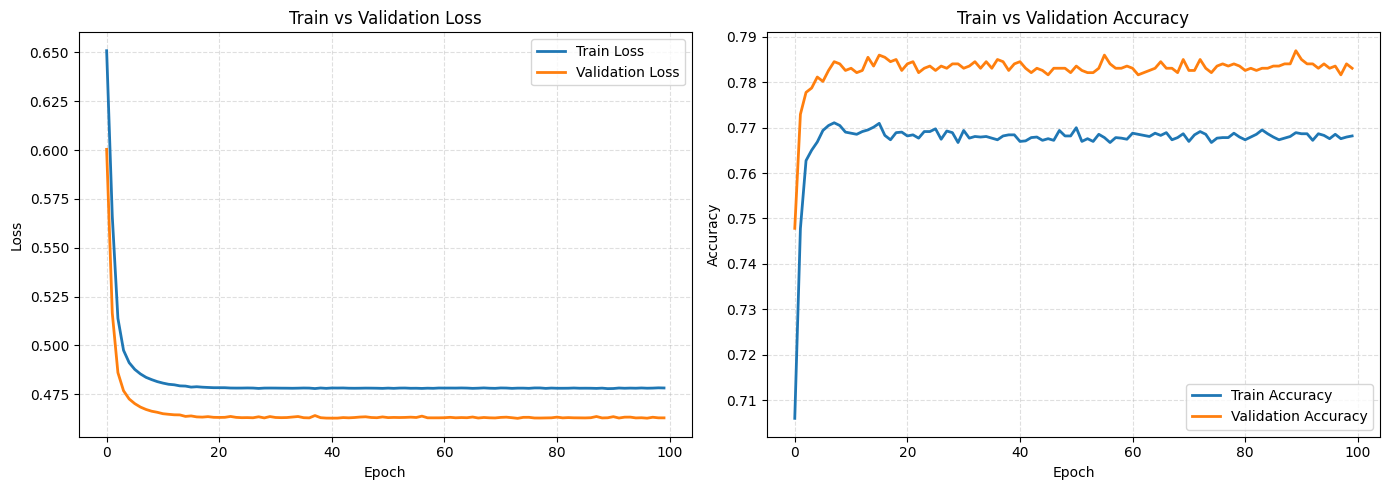

In [418]:
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

# ==== Loss Plot ====
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs_range, val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

# ==== Accuracy Plot ====
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Accuracy", linewidth=2)
plt.plot(epochs_range, val_accs, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()